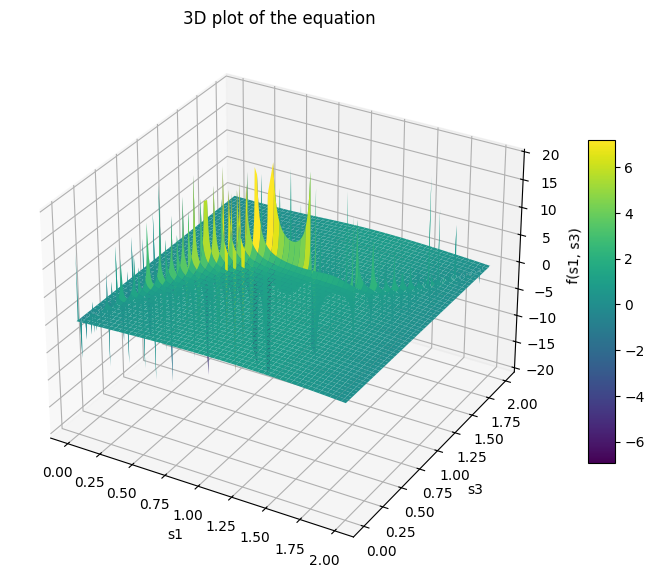

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Symbols
s1, s3 = sp.symbols("s1 s3")

# Equation
expr = 15*s1**2*(s1**3*s3 - 4*s1**3 - 6*s1**2*s3 + 20*s1**2 + 14*s1*s3 - 36*s1 - 12*s3 + 24) / (
    s1**5*s3 + 10*s1**5 - 12*s1**4*s3 - 60*s1**4 + 45*s1**3*s3 + 210*s1**3
    - 90*s1**2*s3 - 360*s1**2 + 90*s1*s3 + 270*s1 - 90*s3
)

# Convert symbolic expression to numerical function
f = sp.lambdify((s1, s3), expr, "numpy")

# Grid of values
s1_vals = np.linspace(0.01, 1.99, 300)
s3_vals = np.linspace(0.01, 1.99, 300)
S1, S3 = np.meshgrid(s1_vals, s3_vals)

# Evaluate
Z = f(S1, S3)

# Remove invalid / singular points
Z = np.array(Z, dtype=float)
Z[~np.isfinite(Z)] = np.nan

# Optional: clip extreme values to improve visualization
Z[np.abs(Z) > 20] = np.nan

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(S1, S3, Z, cmap='viridis', edgecolor='none')

ax.set_xlabel("s1")
ax.set_ylabel("s3")
ax.set_zlabel("f(s1, s3)")
ax.set_title("3D plot of the equation")

fig.colorbar(surf, ax=ax, shrink=0.6, aspect=12)

plt.show()